# Ejercicios para practicar LECTURA Y ESCRITURA DE FICHEROS
Descarga el archivo comprimido que se adjunta con la tarea. Debes descomprimirlo en una carpeta conocida. Este archivo contiene 35 CSVs con los datos de mercado de cada una de las empresas del IBEX 35, el índice bursatil de España.  

**1.**-  Debes escribir un programa que consiga los siguientes objetivos:

1. Lista los archivos con extensión .CSV del directorio donde has descomprimido los 35 archivos e importa los mismos mediante un bucle. Te sugiero que hagas una lista o algún tipo de elemento iterable con todos los dataframes. 
2. Muestra en una gráfica los valores medios diários de cada uno de las empresas (columna 'average') de los meses de octubre, noviembre y diciembre de 2019. Sugerencias:
    - Para filtrar por fecha puedes usar el método loc() del DataFrame. Para crear la fecha de referencia puedes usar el paquete datetime (import datetime as dt) y crearla así "fecha_limite = dt.datetime(2019, 10, 1)". Para transformar todos los strings de fecha de los DataFrames en objetos de tipo datetime puedes usar la siguiente función: "pd.to_datetime(df['Date'],dayfirst=True)".
    - Para hacer la gráfica puedes usar el paquete matplotlib. 
3. Crea un dataframe con las siguientes columnas:
    - Código que identifica a cada empresa.
    - Porcentaje de variación de su valor en la última semana ((ValorFinal-ValorInicial)*100/ValorInicial).
    - Porcentaje de variación de su valor en el último mes.
    - Porcentaje de variación de su valor en el último trimestre.
4. Crea una función que reciba una fecha, importe los datasets de los valores de bolsa y te devuelva el código de empresa que ha subido más en la última semana (en porcentaje).

In [1]:
import os
import pandas as pd

csv_lista = []
lista_df = []

lista_archivos = os.listdir("./IBEX35_Individual_data")

for File in lista_archivos:
    if File.endswith(".csv"):
        csv_lista.append(File)

for csv in csv_lista:
    lista_df.append(pd.read_csv("./IBEX35_Individual_data/" + csv))

lista_df[0].head()

,Ticker,Date,Close,Reference,Volume,Turnover,Last,High,Low,Average
0,BKT,02/01/2019,6.980,7.018,1219753,8444810.91,6.980,7.012,6.800,6.9234
1,BKT,03/01/2019,6.942,6.980,2142728,14868788.05,6.942,7.020,6.880,6.9467
2,BKT,04/01/2019,7.158,6.942,1725530,12294931.88,7.158,7.190,6.976,7.1253
3,BKT,07/01/2019,7.154,7.158,2663550,19012637.34,7.154,7.206,7.092,7.1504
4,BKT,08/01/2019,7.236,7.154,2494581,18030222.18,7.236,7.304,7.150,7.2464


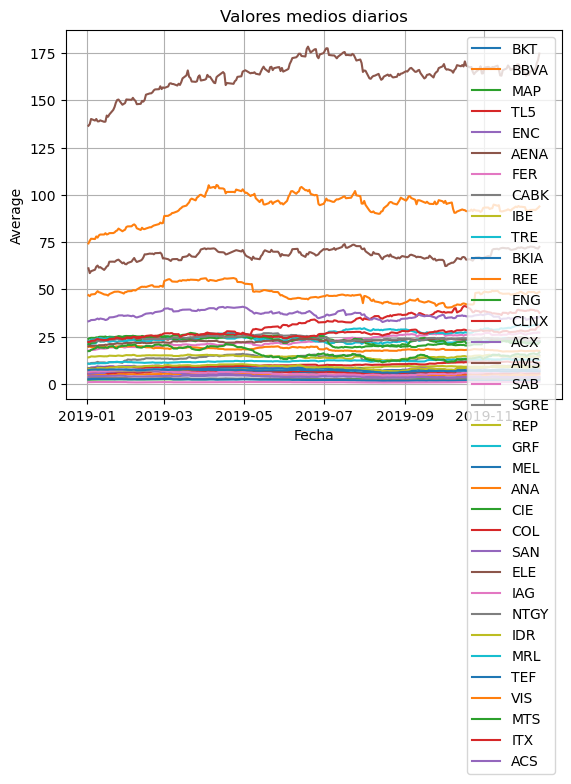

In [2]:
import datetime as dt
import matplotlib.pyplot as plt

fecha_limite = dt.datetime(2019, 10, 1)
fecha_fin = dt.datetime(2019, 12, 31)
leyenda = []

for df in lista_df:
    df["Date"] = pd.to_datetime(df["Date"], dayfirst = True)
    df_filtrado = df.loc[(df["Date"] >= fecha_limite) & (df["Date"] <= fecha_fin)]

    leyenda.append(df["Ticker"].iloc[0])
    plt.plot(df["Date"], df["Average"])

plt.title("Valores medios diarios")
plt.xlabel("Fecha")
plt.ylabel("Average")
plt.legend(leyenda)
plt.grid(True)
plt.show()


In [ ]:
from datetime import date, timedelta
import pandas as pd

codigo_empresa = []
variacion_ultima_semana = []
variacion_ultimo_mes = []
variacion_ultimo_trimestre = []

for df in lista_df:
    # ordenar por fecha
    df = df.sort_values("Date")   

    # cogemos el primer codigo de cada dataframe y lo añadimos
    codigo_empresa.append(df["Ticker"].iloc[0])

    # valores
    fechas = df["Date"]
    valores = df["Average"]

    # cogemos la ultima fecha
    fecha_final = fechas.iloc[-1]

    # cogemos los valores de average en un rango de una semana
    # sacamos la variacion (ValorFinal-ValorInicial)*100/ValorInicial)
    val_ini_sem = valores[fechas >= fecha_final - timedelta(days=7)].iloc[0]
    val_fin_sem = valores[fechas >= fecha_final - timedelta(days=7)].iloc[-1]
    variacion_ultima_semana.append((val_fin_sem - val_ini_sem) * 100 / val_ini_sem)

    # cogemos los valores de average en un rango de un mes
    val_ini_mes = valores[fechas >= fecha_final - timedelta(days=30)].iloc[0]
    val_fin_mes = valores[fechas >= fecha_final - timedelta(days=30)].iloc[-1]
    variacion_ultimo_mes.append((val_fin_mes - val_ini_mes) * 100 / val_ini_mes)

    # cogemos los valores de average en un rango de tres meses 
    val_ini_trim = valores[fechas >= fecha_final - timedelta(days=90)].iloc[0]
    val_fin_trim = valores[fechas >= fecha_final - timedelta(days=90)].iloc[-1]
    variacion_ultimo_trimestre.append((val_fin_trim - val_ini_trim) * 100 / val_ini_trim)

df_variaciones = pd.DataFrame({
    "Codigo": codigo_empresa,
    "Var_Semana (%)": variacion_ultima_semana,
    "Var_Mes (%)": variacion_ultimo_mes,
    "Var_Trimestre (%)": variacion_ultimo_trimestre
})

df_variaciones.head(10)


,Codigo,Var_Semana (%),Var_Mes (%),Var_Trimestre (%)
0,BKT,3.041965,10.130606,13.399366
1,BBVA,4.735452,4.735452,4.143825
2,MAP,-0.065805,2.375287,2.705176
3,TL5,-1.192750,0.375675,-6.310088
4,ENC,0.722898,-0.229781,0.117972
5,AENA,5.737822,7.064855,8.147307
6,FER,1.850923,4.758035,6.430458
7,CABK,2.457852,8.691286,18.430910
8,IBE,2.242925,1.675984,-2.269284
9,TRE,2.166643,-1.909328,-4.163215


In [ ]:
from datetime import datetime, timedelta
import pandas as pd

def funcion(fecha):
    codigo = []
    variacion_ultimasemana = []

    for df in lista_df:

        fecha = pd.to_datetime(fecha)
        # ordenar por fecha
        df = df.sort_values("Date")

        # guardamos el primer codigo de cada dataframe
        codigo.append(df["Ticker"].iloc[0])

        fechas = df["Date"]
        valores = df["Average"]

        # filtrar ultimos 7 dias
        df_sem = df[fechas >= fecha - timedelta(days=7)]

        # ultimo y primero average
        val_ini = df_sem["Average"].iloc[0]
        val_fin = df_sem["Average"].iloc[-1]

        # calculamos la variacion
        variacion = (val_fin - val_ini) * 100 / val_ini
        variacion_ultimasemana.append(variacion)

    df_variacion = pd.DataFrame({
        "Codigo": codigo,
        "Var_Semana (%)": variacion_ultimasemana
    })

    # ordenamos y cogemos el ultimo 
    df_variacion = df_variacion.sort_values("Var_Semana (%)").iloc[-1]
    df_final = pd.DataFrame([df_variacion])

    return df_final

funcion(date(2019, 10, 10))


,Codigo,Var_Semana (%)
26,IAG,43.260004
